# Robust PCA with Nyström Random Sampling

This notebook demonstrates **Robust PCA (RPCA)** for background/foreground
separation in a surveillance video dataset, and compares the standard
block-coordinate-descent approach against an accelerated version that uses
**Nyström random sampling** to reduce runtime.

**Dataset:** `passersby.mat` — 600 grayscale video frames of size 120 × 180 px,
reshaped into a matrix $X \in \mathbb{R}^{21600 \times 600}$.


In [76]:
import time
import random

import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


## 1  Load Data

Load the video frames from `passersby.mat`.  
Each column of `M` is one vectorised frame ($120 \times 180 = 21600$ pixels).


In [77]:
imgs_mat = scipy.io.loadmat("passersby.mat")
M = imgs_mat['X']  # shape: (21600, 600)
print(f"Data matrix shape: {M.shape}")


Data matrix shape: (21600, 600)


### Preview — sample frames from the original video


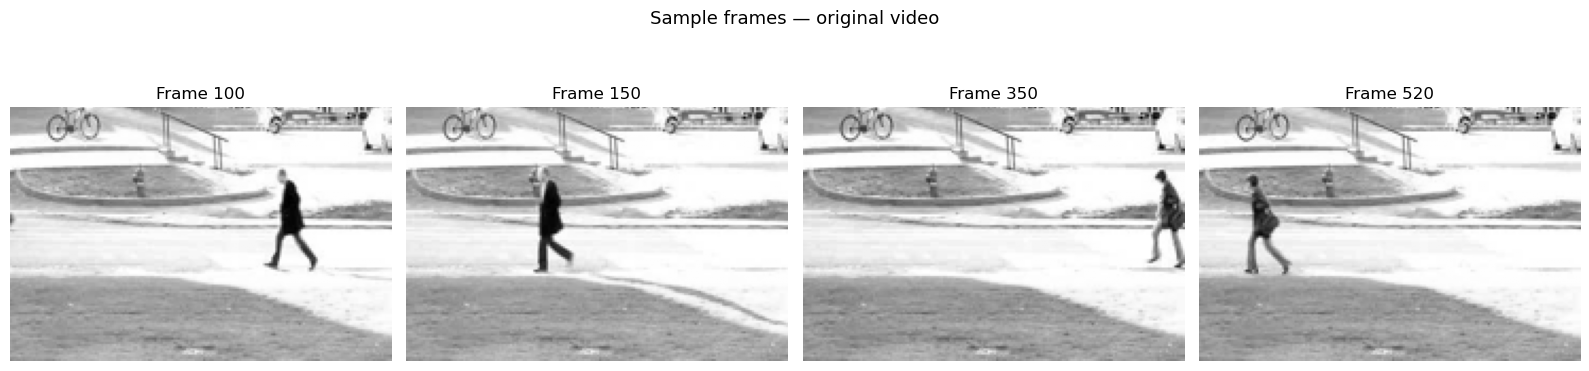

In [78]:
PREVIEW_INDICES = [100, 150, 350, 520]

fig, axes = plt.subplots(1, len(PREVIEW_INDICES), figsize=(16, 4))
for ax, idx in zip(axes, PREVIEW_INDICES):
    ax.imshow(M[:, idx].reshape(180, 120).T, cmap='gray')
    ax.set_title(f"Frame {idx}")
    ax.axis('off')
plt.suptitle("Sample frames — original video", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 2  Robust PCA — Block Coordinate Descent

RPCA decomposes $X$ into a **low-rank** matrix $L$ (static background) and a
**sparse** matrix $S$ (moving foreground) by solving:

$$\min_{L,\,S}\;\|L\|_* + \lambda\|S\|_1 \quad\text{subject to}\quad L + S = X$$

We use the iterative **block coordinate descent** update:

1. Singular-value soft-thresholding to update $L$
2. Element-wise soft-thresholding to update $S$

The soft-threshold operator is defined as
$\mathcal{S}_\tau(x) = \operatorname{sgn}(x)\,\max(|x|-\tau,\,0)$.


In [79]:
def soft_threshold(X: np.ndarray, threshold: float) -> np.ndarray:
    """Element-wise soft-thresholding operator.

    Parameters
    ----------
    X : np.ndarray
        Input array.
    threshold : float
        Threshold value τ.

    Returns
    -------
    np.ndarray
        Array with values shrunk toward zero by *threshold*.
    """
    return np.sign(X) * np.maximum(np.abs(X) - threshold, 0)


def run_rpca(
    M: np.ndarray,
    lam: float = 0.04,
    gamma: float = 4.0,
    n_iters: int = 45,
) -> tuple[np.ndarray, np.ndarray, list[float], float]:
    """Run Robust PCA via block coordinate descent.

    Parameters
    ----------
    M      : Input data matrix.
    lam    : Sparsity regularisation weight (λ).
    gamma  : Singular-value threshold (γ).
    n_iters: Number of BCD iterations.

    Returns
    -------
    L      : Low-rank component.
    S      : Sparse component.
    mses   : MSE at each iteration.
    elapsed: Wall-clock time in seconds.
    """
    L = np.ones(M.shape)
    S = np.ones(M.shape)
    mses = []

    t0 = time.time()
    for _ in range(n_iters):
        # --- update L via SVD soft-thresholding ---
        U, sigma, Vt = np.linalg.svd(M - S, full_matrices=False)
        L = U @ np.diag(soft_threshold(sigma, gamma)) @ Vt

        # --- update S via element-wise soft-thresholding ---
        S = soft_threshold(M - L, lam)

        mses.append(mean_squared_error(M, L + S))
    elapsed = time.time() - t0

    return L, S, mses, elapsed


### 2.1  Run RPCA on the full matrix


In [80]:
L_full, S_full, mses_full, time_full = run_rpca(M)
print(f"RPCA (full) — elapsed: {time_full:.2f} s | final MSE: {mses_full[-1]:.6f}")


RPCA (full) — elapsed: 78.56 s | final MSE: 0.000059


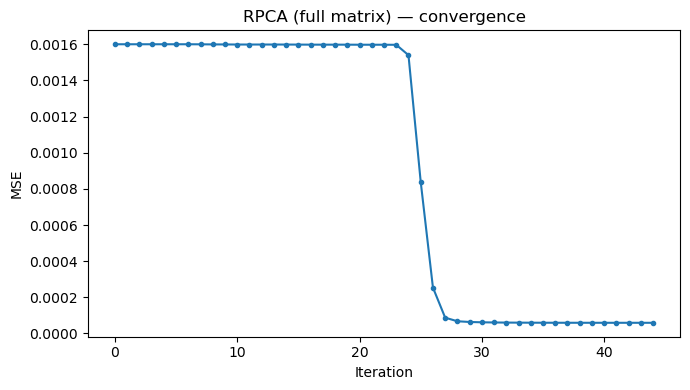

In [81]:
plt.figure(figsize=(7, 4))
plt.plot(mses_full, marker='o', markersize=3)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("RPCA (full matrix) — convergence")
plt.tight_layout()
plt.show()


### 2.2  Visualise background / foreground decomposition


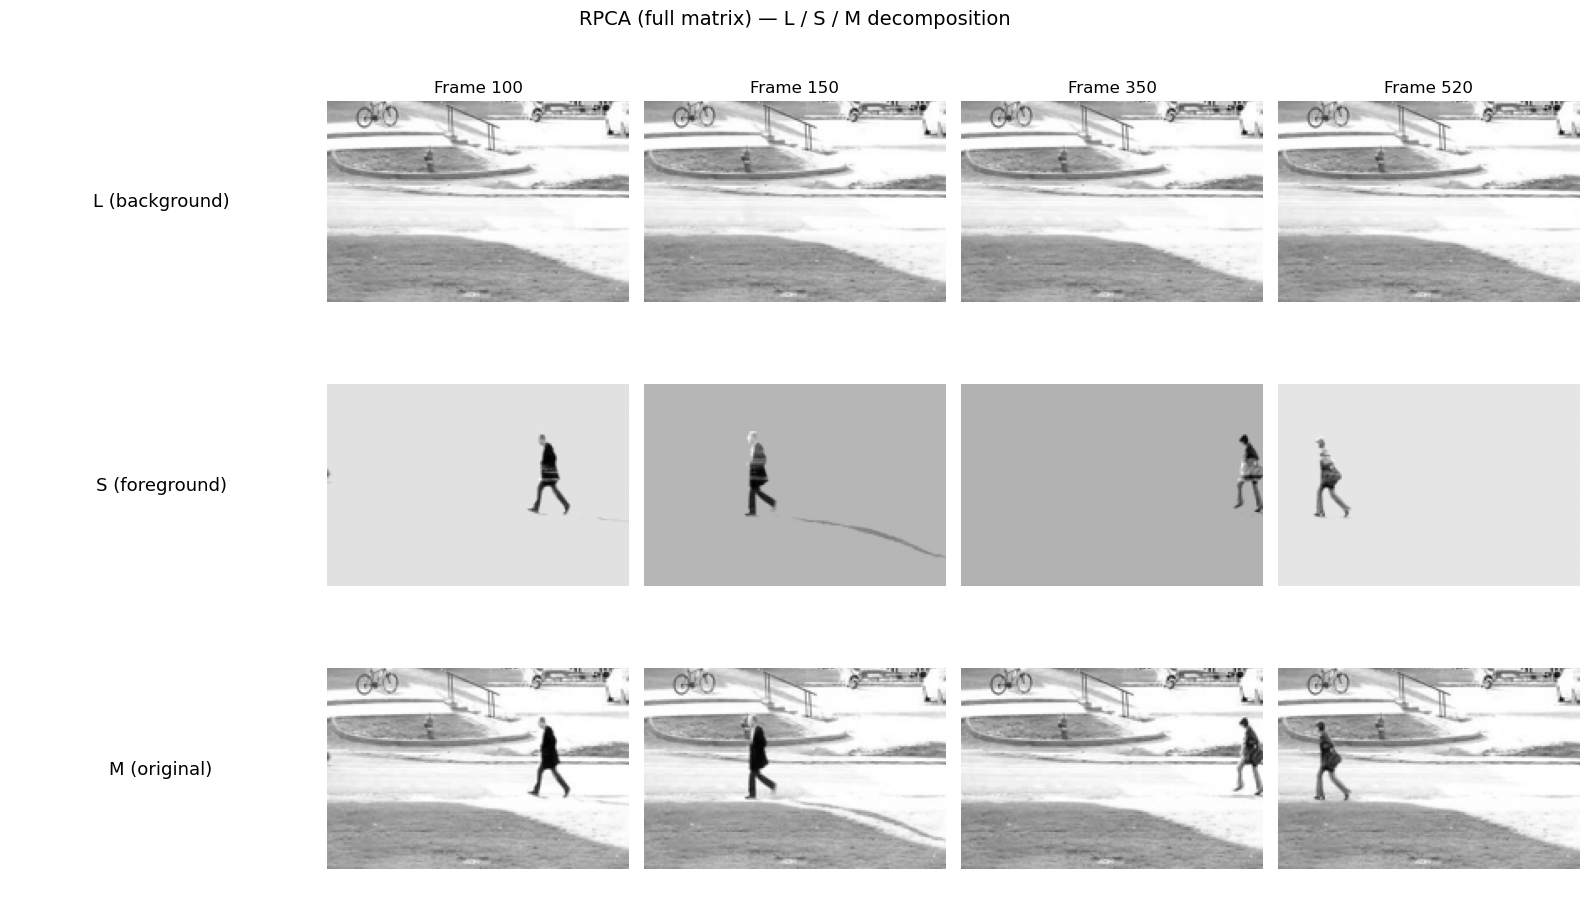

In [82]:
def plot_decomposition(
    L: np.ndarray,
    S: np.ndarray,
    M: np.ndarray,
    indices: list[int],
    title: str = "",
) -> None:
    """Plot L, S, and M side-by-side for selected frame indices."""
    rows = {"L (background)": L, "S (foreground)": S, "M (original)": M}
    fig, axes = plt.subplots(3, len(indices) + 1, figsize=(4 * len(indices), 9))

    for row_idx, (row_label, mat) in enumerate(rows.items()):
        # Left-hand label column
        axes[row_idx, 0].text(0.5, 0.5, row_label, fontsize=13,
                               ha='center', va='center')
        axes[row_idx, 0].axis('off')

        for col_idx, frame_idx in enumerate(indices, start=1):
            axes[row_idx, col_idx].imshow(
                mat[:, frame_idx].reshape(180, 120).T, cmap='gray'
            )
            if row_idx == 0:
                axes[row_idx, col_idx].set_title(f"Frame {frame_idx}")
            axes[row_idx, col_idx].axis('off')

    if title:
        fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


plot_decomposition(
    L_full, S_full, M,
    indices=[100, 150, 350, 520],
    title="RPCA (full matrix) — L / S / M decomposition",
)


## 3  Accelerated RPCA via Nyström Random Sampling

Instead of running RPCA on the full $21600 \times 600$ matrix, we exploit the
**Nyström approximation**:

$$\tilde{X} = C\,U^\dagger R$$

where
* $C \in \mathbb{R}^{21600 \times 60}$ — 10 % of columns sampled at random,
* $R \in \mathbb{R}^{2160 \times 600}$ — 10 % of rows sampled at random,
* $U = R_{:,J}$ — the intersection sub-matrix.

RPCA is run on the smaller $C$ and $R$; the full low-rank matrix is then
reconstructed as $L = L_C \, U^\dagger \, L_R$.


In [83]:
# ── Sample 10 % of columns and 10 % of rows ──────────────────────────────────
n_rows, n_cols = M.shape  # (21600, 600)
J = np.sort(random.sample(range(n_cols), n_cols // 10))  # column indices
I = np.sort(random.sample(range(n_rows), n_rows // 10))  # row indices

C = M[:, J]  # (21600, 60)
R = M[I, :]  # (2160,  600)
print(f"C shape: {C.shape} | R shape: {R.shape}")


C shape: (21600, 60) | R shape: (2160, 600)


In [84]:
# ── RPCA on C and R ───────────────────────────────────────────────────────────
L_C, S_C, mses_C, time_C = run_rpca(C)
L_R, S_R, mses_R, time_R = run_rpca(R)

# ── Nyström reconstruction ────────────────────────────────────────────────────
t0 = time.time()
U_nys = L_R[:, J]                          # intersection sub-matrix
L_nys = L_C @ np.linalg.pinv(U_nys) @ L_R  # low-rank approximation
S_nys = M - L_nys / np.max(L_nys)          # sparse residual (normalised)
time_nys = time_C + time_R + (time.time() - t0)

print(f"RPCA on C  — elapsed: {time_C:.2f} s")
print(f"RPCA on R  — elapsed: {time_R:.2f} s")
print(f"Total (Nyström) — elapsed: {time_nys:.2f} s")
print(f"\nSpeedup vs full RPCA: {time_full / time_nys:.1f}×")


RPCA on C  — elapsed: 3.42 s
RPCA on R  — elapsed: 12.14 s
Total (Nyström) — elapsed: 16.21 s

Speedup vs full RPCA: 4.8×


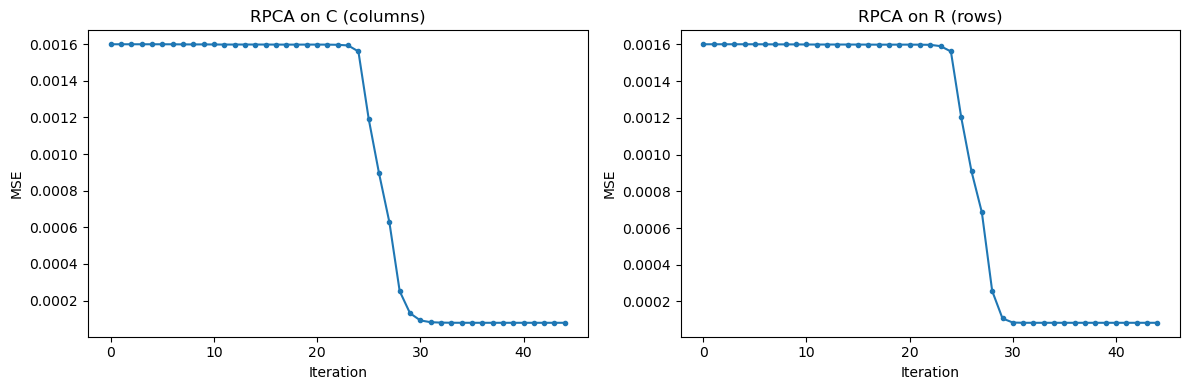

In [85]:
# ── Convergence curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mses, label in zip(axes, [mses_C, mses_R], ["C (columns)", "R (rows)"]):
    ax.plot(mses, marker='o', markersize=3)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("MSE")
    ax.set_title(f"RPCA on {label}")
plt.tight_layout()
plt.show()


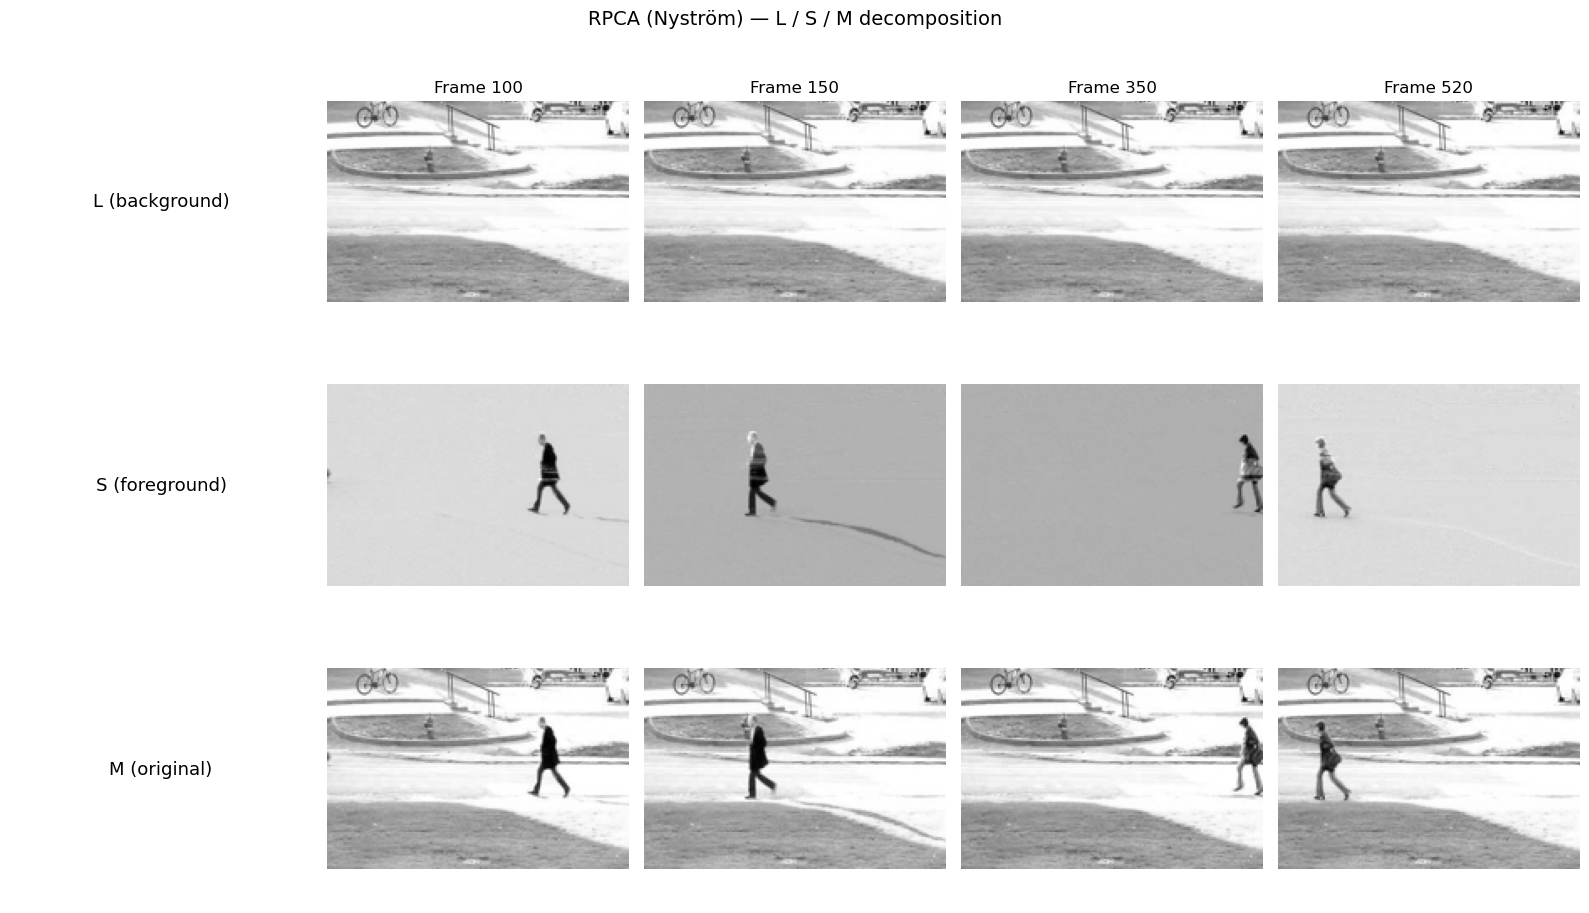

In [86]:
plot_decomposition(
    L_nys, S_nys, M,
    indices=[100, 150, 350, 520],
    title="RPCA (Nyström) — L / S / M decomposition",
)


## 4  Summary


> **Takeaway:** the Nyström approximation achieves a significant speedup by
> running RPCA on two small submatrices ($C$ and $R$) and reconstructing
> the full low-rank component via a pseudo-inverse, also showing a modest improvement in Mean Standard Error.


In [89]:
# MSE of final Nyström reconstruction against original M
M_hat_nys = L_nys + S_nys
mse_nys = mean_squared_error(M, M_hat_nys)
mse_full = mean_squared_error(M, L_full + S_full)

print("=" * 40)
print(f'Final MSE RPCA        : {mse_full}')
print(f"Final MSE RPCA Nystrom: {mse_nys}")

print("=" * 40)

Final MSE RPCA        : 5.918549628786604e-05
Final MSE RPCA Nystrom: 3.93050427430623e-06


In [88]:
speedup = time_full / time_nys
print("=" * 40)
print(f"Full RPCA elapsed   : {time_full:.2f} s")
print(f"Nyström RPCA elapsed: {time_nys:.2f} s")
print(f"Speedup             : {speedup:.1f}×")
print("=" * 40)


Full RPCA elapsed   : 78.56 s
Nyström RPCA elapsed: 16.21 s
Speedup             : 4.8×
